# Datasets Preparation

START DATASETS PREPARATION
verbose is True
>> imports
>> load trajectories


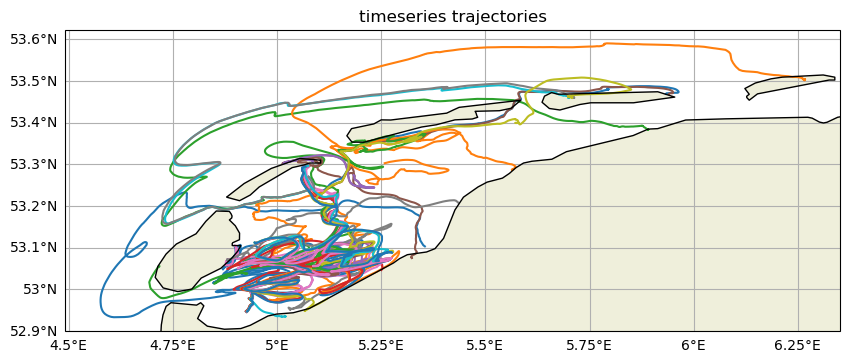

>> load bathymetry
imshow gives 2nd index on X axis and 1st index on Y axis
squares : show orientation of data. darkest is origin, middle is 1st index max, brigthest is 2nd index max
(10139, 5185)
[4.3813815 4.3816843 4.3819876 ... 7.4529176 7.453221  7.4535236]
10139
[52.79103  52.791214 52.791397 ... 53.739372 53.739555 53.73974 ]
5185


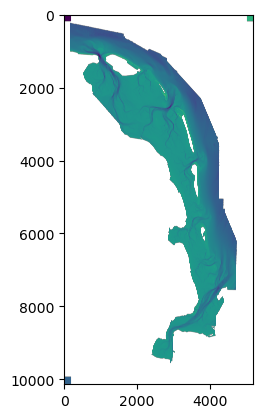

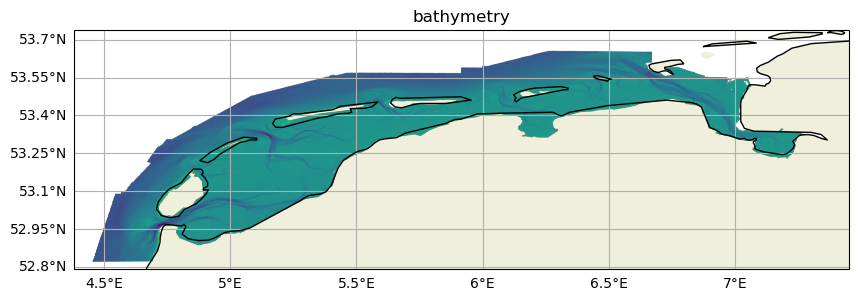

>> load waterlevel
structure before parsing
dict_keys(['time', 'set'])
dict_keys(['lon', 'lat', 'level'])
structure after parsing
dict_keys(['times', 'lons', 'lats', 'vals'])


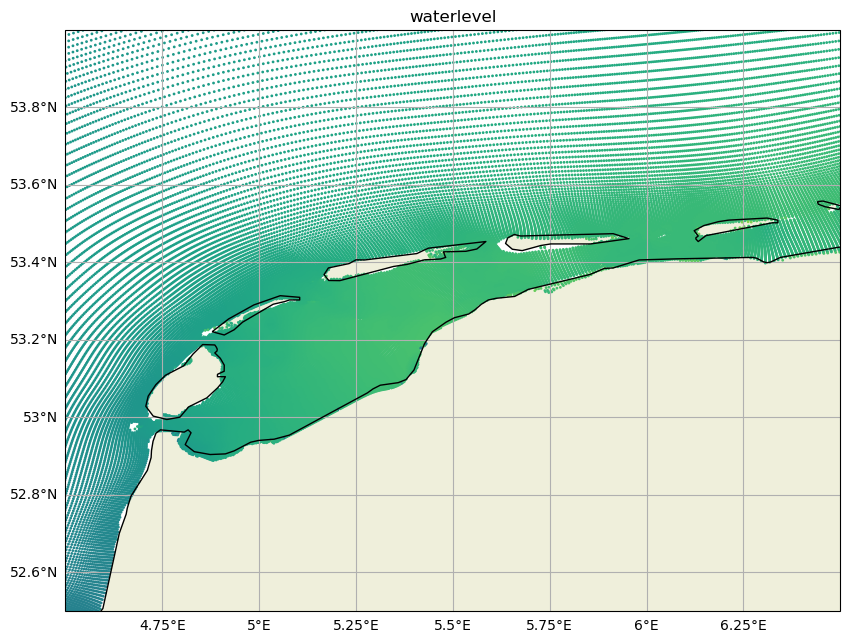

>> load wind
>> preprocessing bathymetry
resolution original dataset x~20.324686m and y~20.324707m
resolution downscaled x~101.718607m and y~101.623535m


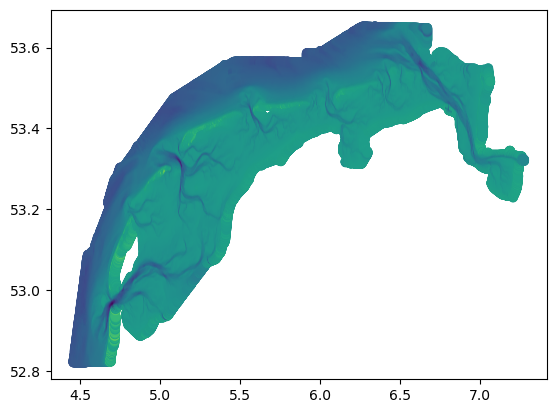

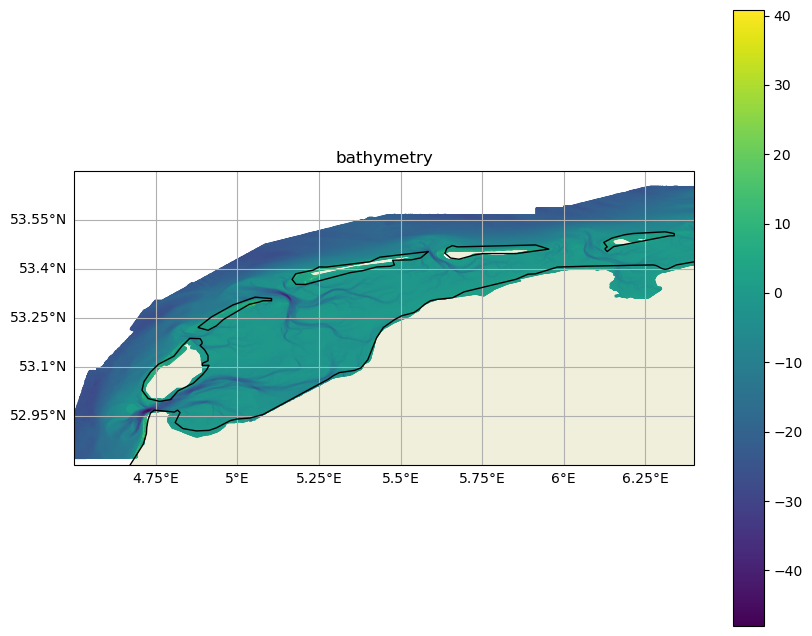

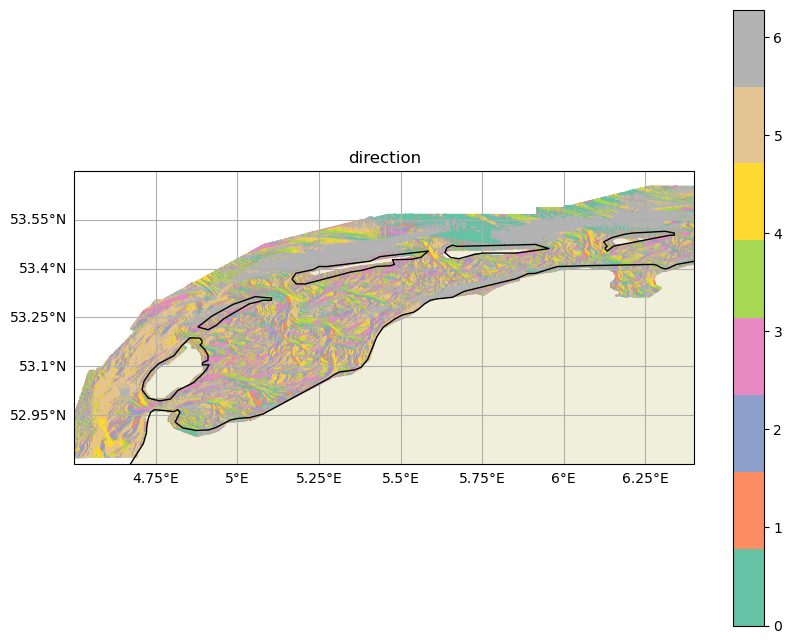

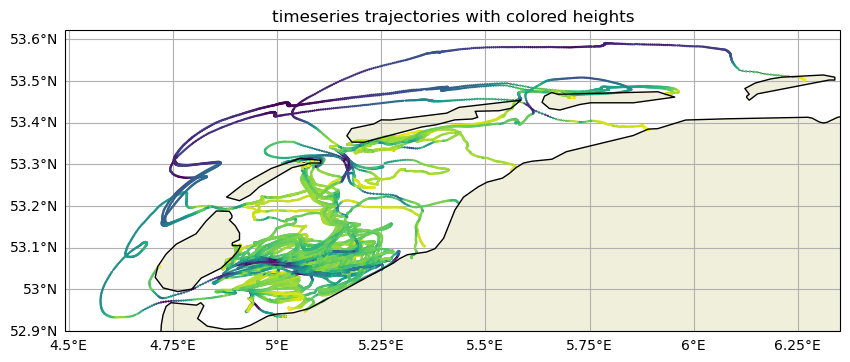

>> preprocessing wind
<xarray.DataArray 'valid_time' ()> Size: 8B
array('2023-11-01T00:00:00.000000000', dtype='datetime64[ns]')
Coordinates:
    number      int64 8B ...
    valid_time  datetime64[ns] 8B 2023-11-01
    expver      <U4 16B ...
Attributes:
    long_name:      time
    standard_name:  time


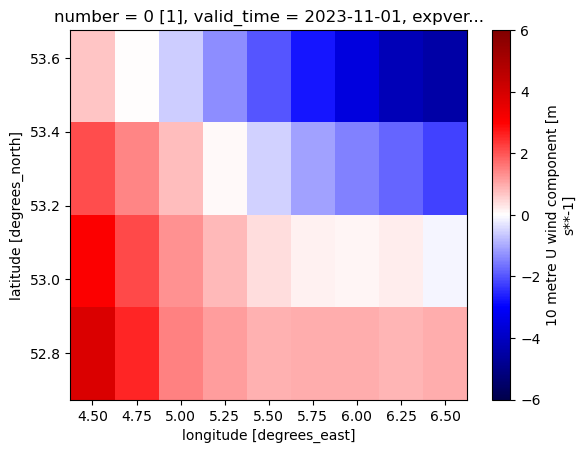

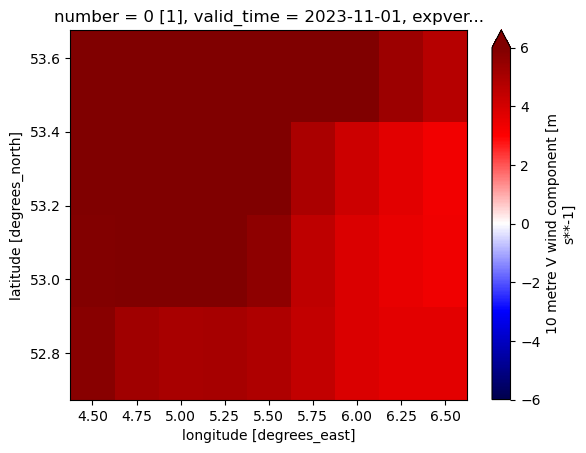

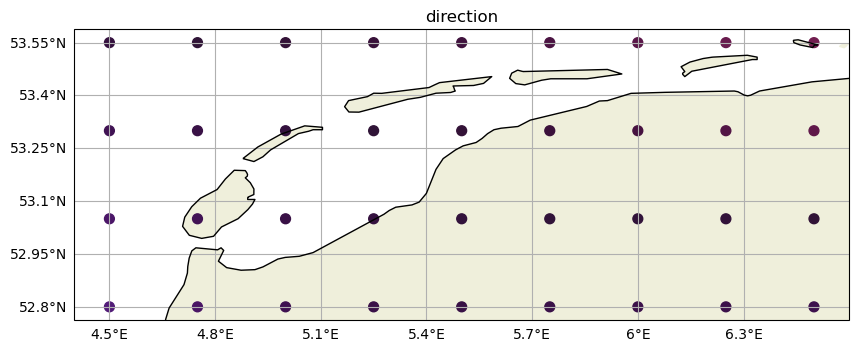

[9.86283273e-02 3.14844400e-01 4.73938286e-01 5.88199139e-01
 4.37219162e-03 2.01450020e-01 3.30025911e-01 4.51671809e-01
 6.20580578e+00 1.02269500e-01 1.97678313e-01 2.89350301e-01
 6.11628485e+00 1.05228387e-02 1.30931467e-01 2.19666779e-01
 6.02238464e+00 6.19804525e+00 6.72390461e-02 1.85046032e-01
 5.89434338e+00 6.06714582e+00 3.33250314e-02 2.14398876e-01
 5.75142384e+00 5.93979311e+00 2.90516745e-02 2.40780577e-01
 5.61669588e+00 5.82316828e+00 5.40761761e-02 2.38645166e-01
 5.52496576e+00 5.68720484e+00 6.24868631e+00 2.62457132e-01]


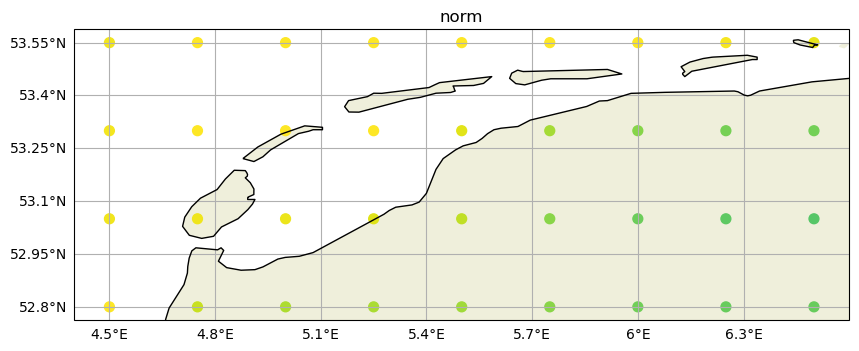

[6.71786451 6.73721266 6.68800879 6.956635   7.28684902 7.11897564
 6.62243795 5.81362534 7.85300255 7.4145093  6.57547998 5.25065756
 8.04975891 7.08795309 6.34203911 5.20594501 7.75583982 6.35778236
 5.65943146 4.99249601 7.27849197 5.13365507 4.50265837 4.51365709
 6.94428873 4.44833803 3.8535912  3.96575832 6.79765081 4.09436798
 3.53449965 3.75991583 6.50285578 3.99949074 3.33026505 3.77190375]
>> defining misc shared methods
DONE DATASETS PREPARATION


In [1]:
%run ./2_0_datasets_preparation.ipynb

# Parameters

In [2]:
verbose = True
plot_dir = "plot/"

# Parameters

In [3]:
surroundings_distance_meters = 1000.
tmin,tmax = 1699920000, 1701388800
pCT = [5.242308390, 53.216548680]
pNW = [4.967661231, 52.990785512]
pSE = [5.622440284, 53.369652522]
pWS = [pCT, pNW, pSE]

# 1: Plots

### Wind and Sea conditions

TODO: adjust labels placement, took to long to do in the script here
[35.7 40.3 24. ]
No timesteps 409 != sum of histo counts 409


/var/folders/34/nx9zlnqn1z1cr2gtrfzmz7vw0000gp/T/ipykernel_88011/3470335329.py:64: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(prop={'size': 8},bbox_to_anchor=(0.5,-0.25), loc="lower center",ncols=3, frameon=False)


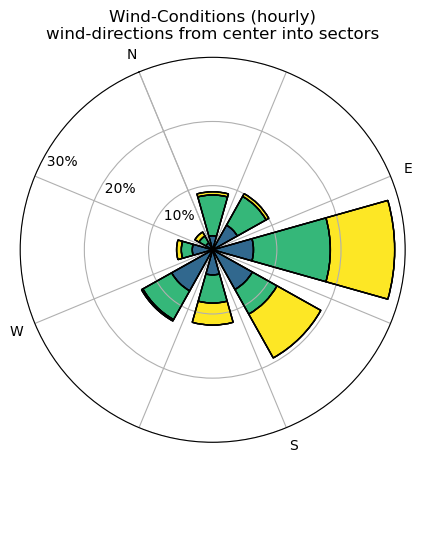

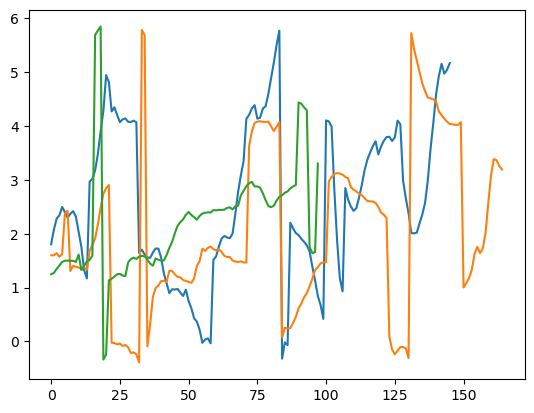

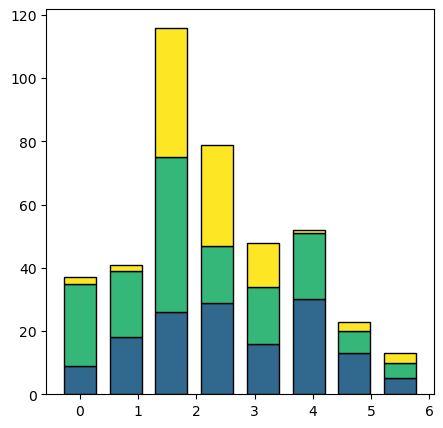

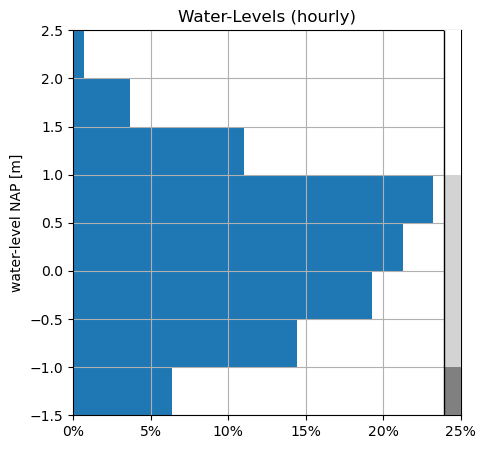

In [4]:
from matplotlib.ticker import PercentFormatter

def sample_cmap_rgb(v, vrange=[0.0,1.0], cmap_str='viridis'):
  cmap = mpl.colormaps.get_cmap(cmap_str)
  norm = mpl.colors.Normalize(vmin=vrange[0],vmax=vrange[1])
  rgb = cmap(norm(v))[:3]
  return rgb

tmin,tmax = 1699920000, 1701388800

p_sample = pWS[0]
times_sample = np.array(range(tmin,tmax+1,60*60))

water_level = np.zeros(times_sample.shape[0])
wind_direction = np.zeros(times_sample.shape[0])
wind_speed = np.zeros(times_sample.shape[0])
wind_U = np.zeros(times_sample.shape[0])
wind_V = np.zeros(times_sample.shape[0])
lon, lat = p_sample
for it, t in enumerate(times_sample):
  water_level[it] = utils.sample_nearest_mesh_value(swanwaterlevel,{"lon":lon, "lat":lat, "time":t})[0]
  wind_direction[it], wind_speed[it], wind_U[it], wind_V[it] = get_wind_conditions(lon, lat, t)
categories_wind_direction = np.array([[(i-.5)/8.*(2*np.pi),(i+1-.5)/8.*(2*np.pi)] for i in range(8)])
labels_wind_direction = ['N','NE','E','SE','S','SW','W','NW']
categories_wind_speed = np.array([[0,6],[6,12],[12,np.inf]])
labels_wind_speed = ['< 6 m/s','6-12 m/s','12-18 m/s']

x_range = [(0.-.5)/8.*(2*np.pi),(8-.5)/8.*(2*np.pi)]
hatching = [[],[''],['',''],['','',''],['','','','']]
max_count_bins = 122
figsize_xy=5
n10_bins = int(max_count_bins/10)
fig, ax = plt.subplots(subplot_kw=dict(projection="polar"),figsize=(figsize_xy,figsize_xy))
plt.title("Wind-Conditions (hourly)\nwind-directions from center into sectors")
ax.set_theta_zero_location("N")
ax.set_rlabel_position(-65)
ax.set_theta_direction(-1)
ax.set_xlim(x_range[0],x_range[1])
ax.set_xticks(np.linspace(x_range[0],x_range[1],8+1),['N','','E','','S','','W','',''])#['N','','','','E','','','','S','','','','W','','','',''])
print("TODO: adjust labels placement, took to long to do in the script here")
N = wind_speed.shape[0]
pmax_xaxis = 30
ax.set_ylim([0,pmax_xaxis])
ax.set_yticks(np.array(range(10,pmax_xaxis+1,10))/100*N,["  %d%%"%p for p in range(10,pmax_xaxis+1,10)])
#ax.set_ylim(0,max_count_bins+1)
#ax.set_yticks([0,20,40,60,80,100,120],['','','40','60','80','100','120'])
ax.grid(zorder=30)
#ax.set_xticks(np.linspace(0,2*np.pi,16+1),['N','','','','E','','','','S','','','','W','','','',''], minor=True)#['N','','','','E','','','','S','','','','W','','','',''])
#ax.grid(which='minor', alpha=0,zorder=-100)

wind_direction[wind_direction>=(8-.5)/8.*(2*np.pi)] -= 2*np.pi
data_hist = [wind_direction[(cws[0]<=wind_speed)*(wind_speed<cws[1])] for cws in categories_wind_speed]
cnt_categories_wind_speed = np.array([np.sum((cws[0]<=wind_speed)*(wind_speed<cws[1])) for cws in categories_wind_speed])
print(np.round(100*cnt_categories_wind_speed/np.sum(cnt_categories_wind_speed),decimals=1))
print("No timesteps %d != sum of histo counts %d" % (times_sample.shape[0],np.sum([data_hist[i].shape for i in range(len(categories_wind_speed))])))
colors_hist = [sample_cmap_rgb(v,[0,18.]) for v in [6,12,18]] #['dodgerblue','lightskyblue','lightcyan','w']
#hatching_hist = [hatching[len(categories_O1[ct])][i] for label in histo_labels for i in range(len(categories_O1[ct]))]
#ax.hist(DB, bins=n_bins, range=x_range, stacked=True,color=[label_color[l][1] for l in histo_labels],zorder=-10)
n_bins = 8
mpl.rcParams['hatch.linewidth'] = 1
ax.hist(data_hist, bins=n_bins, range=x_range, color=colors_hist, zorder=-10, histtype="barstacked", edgecolor='black',linewidth=1, rwidth=0.7) #, histtype="barstacked", stacked=True #, hatch=hatching_hist
ax.hist(data_hist, bins=n_bins, range=x_range, color=[(0.,0.,0.,0.) for i in range(len(colors_hist))], zorder=10, histtype="barstacked", edgecolor='black',linewidth=1, rwidth=0.7)
ax.hist(np.concatenate(data_hist,axis=0), bins=n_bins, range=x_range, color=(0.,0.,0.,0.), edgecolor='black',zorder=10,linewidth=1, rwidth=0.7)
ax.legend(prop={'size': 8},bbox_to_anchor=(0.5,-0.25), loc="lower center",ncols=3, frameon=False)

#plt.savefig("%s/windrose_%s"%(plot_dir,ct))
plt.show()

for wds in data_hist:
  plt.plot(wds)
plt.show()

fig, ax = plt.subplots(figsize=(figsize_xy,figsize_xy))
ax.hist(data_hist, bins=8, range=x_range, color=colors_hist, zorder=-10, histtype="barstacked", edgecolor='black',linewidth=1, rwidth=0.7)
plt.show()
3
colors_bathymetry = ['white','lightgrey','grey','black']
fig, ax = plt.subplots(figsize=(figsize_xy,figsize_xy))
plt.title("Water-Levels (hourly)")
wl_range = [-1.5,2.5]
N = water_level.shape[0]
ax.hist(water_level,bins=8,range=wl_range, orientation='horizontal')
ax.set_ylim(wl_range)
pmax_xaxis = 25
ax.set_xlim([0,pmax_xaxis])
ax.set_xticks(np.array(range(0,pmax_xaxis+1,5))/100*N,["%d%%"%p for p in range(0,pmax_xaxis+1,5)])
ax.bar(98,-1.5,5,color=colors_bathymetry[2],align='edge',zorder=10)
ax.bar(98,2.5,5,color=colors_bathymetry[0],align='edge',zorder=10)
ax.bar(98,1,5,color=colors_bathymetry[1],align='edge',zorder=10)
ax.bar(98,-1,5,color=colors_bathymetry[1],align='edge',zorder=10)
ax.vlines(98,-1.5,2.5,colors='black',lw=1,zorder=11)
ax.vlines(103,-1.5,2.5,colors='black',lw=1,zorder=11)
ax.set_ylabel("water-level NAP [m]")
plt.grid(zorder=100)
plt.show()


### Campaign overview

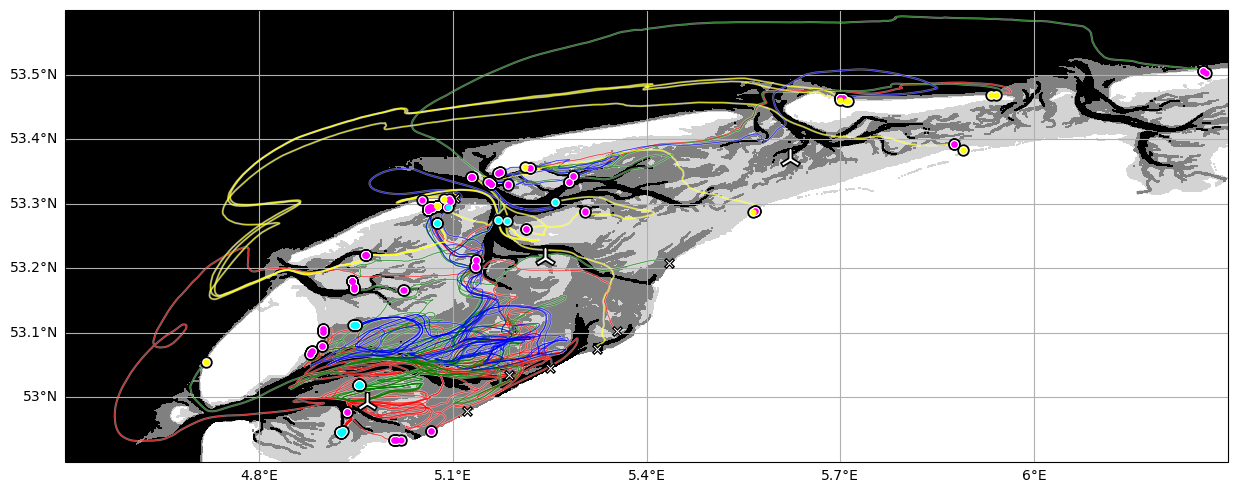

<Figure size 32000x24000 with 0 Axes>

<xarray.Dataset> Size: 388kB
Dimensions:              (index: 2655, index_original: 2655)
Coordinates:
  * index                (index) int64 21kB 0 1 2 3 4 ... 2651 2652 2653 2654
  * index_original       (index_original) int64 21kB 0 1 2 3 ... 2652 2653 2654
Data variables: (12/18)
    time                 (index) float64 21kB ...
    lon                  (index) float64 21kB 4.925 4.926 4.927 ... 5.354 5.355
    lat                  (index) float64 21kB 52.95 52.95 52.95 ... 53.1 53.1
    orientation          (index) float64 21kB ...
    sst                  (index) float64 21kB ...
    t                    (index) float64 21kB ...
    ...                   ...
    dx                   (index) float64 21kB ...
    dy                   (index) float64 21kB ...
    label                (index) float64 21kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    grounded             (index) bool 3kB ...
    beached              (index) bool 3kB ...
    dt_section           (index) float64 21kB ...
Attributes:
    i_record:                       0
    i_ts:                           0
    drifter_name:                   <xarray.DataArray 'trajectory' ()> Size: ...
    stdev_position_meters:          6.405357115545444
    units:                          meters for distances, seconds for times, ...
    preprocessing_min_dt:           200
    preprocessing_max_dt:           1700
    preprocessing_min_ts_duration:  5400
    preprocessing_min_ts_nsamp:     36

In [5]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import cartopy.crs as ccrs

groups = {
  'A':{
    'A1':[[0],[1],[3]], #3 purple/red/darkorange
    'A2':[[4],[6],[7]], #3 purple/red/darkorange
    'A3':[[8],[9],[10]], #3 purple/red/darkorange
  },
  'B':{
    'B1':[[11],[12],[13]], #3 green/olive/lime
    'B2':[[14],[15]], #3 green/olive/lime
    'B3':[[16,17],[18],[20]], #3 green/olive/lime
  },
  'C':{
    'C1':[[28],[29],[30]], #2 blue/cyan
    'C2':[[22],[23],[26]], #2 blue/cyan
  },
  'D':{
    'D1':[[2],[5],[19],[21],[24],[27]], #1
  },
  'E':{
    'E1':[[25]], #1
  }
}
colors_wsc = {
  'A':'red',
  'B':'green',
  'C':'blue',
  'D':'yellow',
  'E':'yellow',
  'A1':'purple',
  'A2':'red',
  'A3':'darkorange',
  'B1':'green',
  'B2':'olive',
  'B3':'lime',
  'C1':'blue',
  'C2':'cyan',
  'D1':'yellow',
  'E1':'yellow',
}
markers = {
  'A':'o',#'^',
  'B':'o',#'v',
  'C':'o',#'<',
  'D':'o',#'>',
  'E':'o',#'>',
}

extent_wsc=[[4.5,6.3],[52.9,53.6]]
fig, ax = utils.map_plot("", figsize=(15,15), add_land_coastline=[False,False], extent=extent_wsc, grid_ticks=[7,8])
plt.figure(dpi=5000)
for group_key in groups.keys(): #colors_wsc[group_key]
  for subgroup_key in groups[group_key].keys():
    for g in groups[group_key][subgroup_key]:
      size, scale = 20, 2
      release_lon, release_lat = trajectories[g[0]].lon.values[0], trajectories[g[0]].lat.values[0]
      ax.scatter(release_lon, release_lat, s=size*scale*2,c='black', marker=markers[group_key],linewidths=0, zorder=18)
      ax.scatter(release_lon, release_lat, s=size*scale,c='w', marker=markers[group_key],linewidths=0, zorder=19)
      ax.scatter(release_lon, release_lat, s=size,c='cyan', marker=markers[group_key],linewidths=0, zorder=20)
      for i in g:
        inds = (trajectories[i].label.values==-1.0)+(trajectories[i].label.values==1.0)
        lons, lats = trajectories[i].lon.values[inds], trajectories[i].lat.values[inds]
        ax.scatter(lons, lats, s=size*scale*2,c='black', marker=markers[group_key],linewidths=0, zorder=18)
        ax.scatter(lons, lats, s=size*scale,c='w', marker=markers[group_key],linewidths=0, zorder=19)
        ax.scatter(lons, lats, s=size,c='magenta', marker=markers[group_key],linewidths=0, zorder=20)
        inds = (trajectories[i].label.values==2.0)
        lons, lats = trajectories[i].lon.values[inds], trajectories[i].lat.values[inds]
        ax.scatter(lons, lats, s=size*scale*2,c='black', marker=markers[group_key],linewidths=0, zorder=18)
        ax.scatter(lons, lats, s=size*scale,c='w', marker=markers[group_key],linewidths=0, zorder=19)
        ax.scatter(lons, lats, s=size,c='yellow', marker=markers[group_key],linewidths=0, zorder=20)
        if(2.0 not in np.unique(trajectories[i].label.values)):
          lons, lats = trajectories[i].lon.values[-1], trajectories[i].lat.values[-1]
          ax.scatter(lons, lats, s=size*scale,c='black', marker='x',linewidths=2.5, zorder=14)
          ax.scatter(lons, lats, s=size*scale*0.6,c='w', marker='x',linewidths=0.7, zorder=15)
      for i in g:
        ax.plot(trajectories[i].lon.values, trajectories[i].lat.values,lw=1.5,color='w', zorder=9,alpha=0.5)
        ax.plot(trajectories[i].lon.values, trajectories[i].lat.values,lw=0.8,color=colors_wsc[group_key], zorder=10,alpha=0.5)
        ax.plot(trajectories[i].lon.values, trajectories[i].lat.values,lw=0.2,color=colors_wsc[group_key], zorder=10,alpha=1)

heights = [np.inf,1.0,-1.0,-5.0,-np.inf]
colors = ['white','lightgrey','grey','black']
for i in range(len(heights)-1):
  range_max, range_min = heights[i], heights[i+1]
  inds = (range_min<=vals_mesh)*(vals_mesh<range_max)
  ax.scatter(bathymetry["lons"][inds], bathymetry["lats"][inds], transform=ccrs.PlateCarree(), zorder=-10,marker='s',s=1.5,linewidths=0,color=colors[i])
  ax.fill([4.5,4.8,5.25,6.3,4.5], [52.9,53.3,53.5,53.6,53.6], 'black', zorder=-11)

ax.scatter([p[0] for p in pWS],[p[1] for p in pWS],lw=4,marker='2',s=270,c='black',zorder=30)
ax.scatter([p[0] for p in pWS],[p[1] for p in pWS],lw=1.5,marker='2',s=200,c='white',zorder=31)

plt.draw()
fig.savefig(plot_dir+'campaignrecords.png', dpi=300)
fig.savefig(plot_dir+'campaignrecords.svg')
plt.show()

trajectories[0] if verbose else None

### Context map

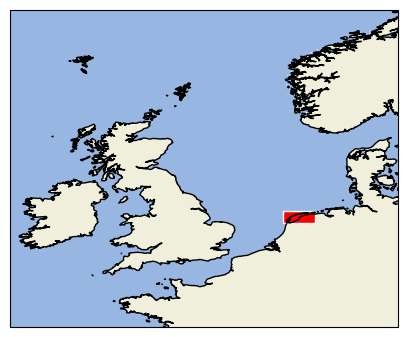

In [6]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.patches as patches

figsize=(5,5)
extent=[[-11,11],[47,65]]
grid_ticks=[0,0]

fig = plt.figure(figsize=figsize)
ax = plt.axes(projection=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE.with_scale('10m'),lw=1, zorder=20)
ax.add_feature(cfeature.OCEAN.with_scale('10m'), zorder=0)
ax.add_feature(cfeature.LAND.with_scale('10m'), zorder=0)
ax.set_xlim(extent[0])
ax.set_ylim(extent[1])
rect = patches.Rectangle((extent_wsc[0][0],extent_wsc[1][0]),extent_wsc[0][1]-extent_wsc[0][0],extent_wsc[1][1]-extent_wsc[1][0], linewidth=1, edgecolor='white', facecolor="r", zorder=10)
ax.add_patch(rect)

plt.draw()
fig.savefig(plot_dir+'campaignmap.png', dpi=300)
fig.savefig(plot_dir+'campaignmap.svg')
plt.show()

### Timeline

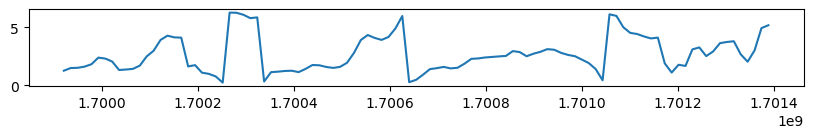

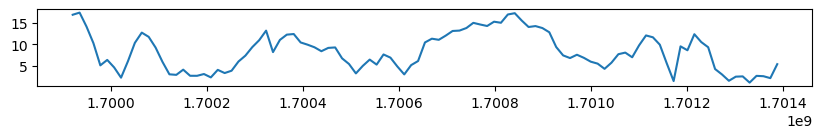

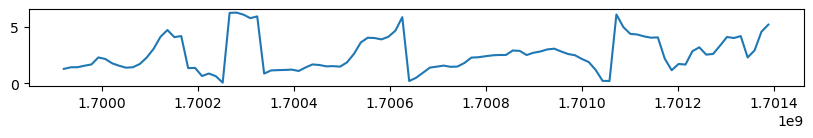

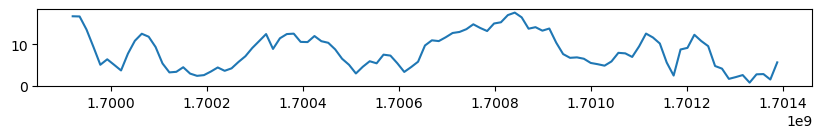

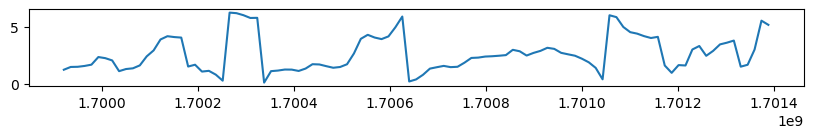

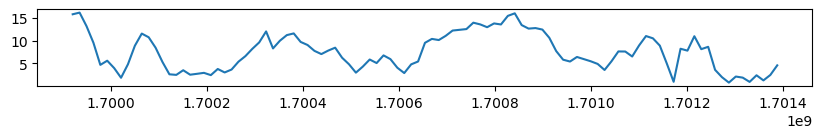

In [7]:
import utils

#def get_waterlevel(lon, lat, time):
#  

pCT = [5.242308390, 53.216548680]
pNW = [4.967661231, 52.990785512]
pSE = [5.622440284, 53.369652522]
surroundings_distance_meters = 1000.
n_times_wind = 103
n_times_water = 409

trajectories, N_traj = load_trajectories("data/out/sample_interval_1_rnd_drop_fraction_0.00/")
tmin, tmax = np.nan, np.nan
for tr in trajectories:
  times = tr.time.values
  tmin, tmax = np.nanmin([tmin,np.nanmin(times)]), np.nanmax([tmin,np.nanmax(times)])
tmin,tmax = 1699920000, 1701388800
pWS = [pCT, pNW, pSE]

times_wind = np.linspace(tmin,tmax,n_times_wind)
times_water = np.linspace(tmin,tmax,n_times_water)

water_level = []
wind_directions = []
wind_speeds = []
wind_U = []
wind_V = []
for ipos, pos in enumerate(pWS):
  lon, lat = pos
  #water_levels[i_time,0], _, water_levels[i_time,1:] = utils.sample_nearest_mesh_value(swanwaterlevel,{"lon":lon, "lat":lat, "time":times_sec[i_time]},surroundings_distance_meters)
  water_level += [np.array([utils.sample_nearest_mesh_value(swanwaterlevel,{"lon":lon, "lat":lat, "time":t})[0] for t in times_water])]
  wind_directions += [np.array([get_wind_conditions(lon, lat, t)[0] for t in times_wind])]
  wind_speeds += [np.array([get_wind_conditions(lon, lat, t)[1] for t in times_wind])]
  wind_U += [np.array([get_wind_conditions(lon, lat, t)[2] for t in times_wind])]
  wind_V += [np.array([get_wind_conditions(lon, lat, t)[3] for t in times_wind])]
  if verbose:
    plt.figure(figsize=(10,1))
    plt.plot(times_wind,wind_directions[-1])
    plt.show()
    plt.figure(figsize=(10,1))
    plt.plot(times_wind,wind_speeds[-1])
    plt.show()


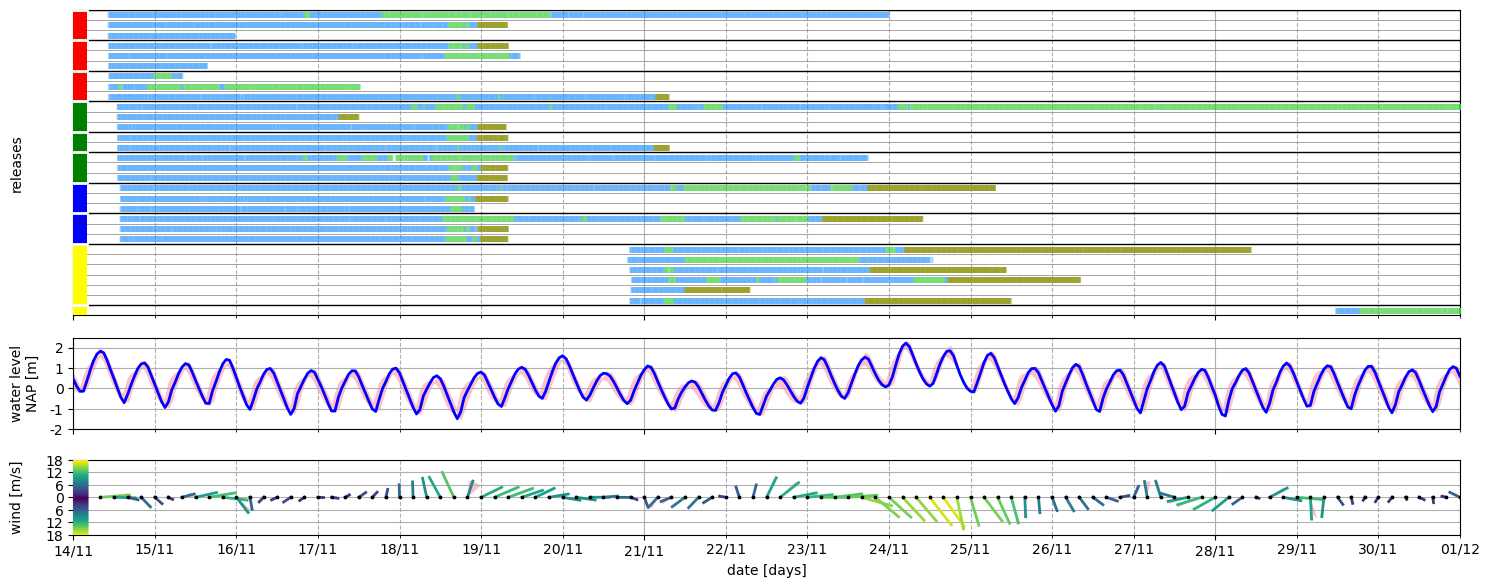

In [8]:
import matplotlib.patches as patches

label_color = {'W':['dodgerblue','lightskyblue','lightcyan','w'],'D':['limegreen','lightgreen','honeydew','w'],'B':['darkgoldenrod','tan','antiquewhite','w']}

from scipy.interpolate import interp1d
import matplotlib

#fig, axs = plt.subplots(rows=3, figsize=[6, 3])

def sample_cmap_rgb(v, vrange=[0.0,1.0], cmap_str='viridis'):
  cmap = matplotlib.colormaps.get_cmap(cmap_str)
  norm = matplotlib.colors.Normalize(vmin=vrange[0],vmax=vrange[1])
  rgb = cmap(norm(v))[:3]
  return rgb

trajectories, N_traj = load_trajectories("data/out/sample_interval_1_rnd_drop_fraction_0.00/")

time_min,time_max = 1699920000, 1701388800
s_per_week = 604800
s_per_day = 86400
wind_speed_min, wind_speed_max = np.floor(np.min(wind_speeds)), np.ceil(np.max(wind_speeds))
xlim = 1
ratio_ylim_xlim = 20
wind_speed_max_length = 0.027
figure_scale = 15
xticks = [interp1d([time_min,time_max],[0,xlim])(t) for t in range(time_min,time_max+1,s_per_week)]
xmticks = [interp1d([time_min,time_max],[0,xlim])(t) for t in range(time_min,time_max+1,s_per_day)]

xwidth = xlim
ywidth = xlim/ratio_ylim_xlim
xrange = [0.0, xwidth]
yrange = [-0.5*ywidth, 0.5*ywidth]
figure_size_xy = [xwidth*figure_scale, ywidth*figure_scale]

times_wind_rescaled = interp1d([time_min,time_max],[0,xlim])(times_wind)
times_water_rescaled = interp1d([time_min,time_max],[0,xlim])(times_water)

fig, (axtimeline, axwaterlvl, axwind) = plt.subplots(3,1,height_ratios=[5,1.5,1.5])
fig.set_size_inches(figure_size_xy[0],figure_size_xy[1]*8)

# timeline
#trajectories = [trajectories[iasc] for iasc in np.argsort([tr.time.values[0] for tr in trajectories])] #sort trajectories by timestamp
#i_records = np.unique([tr.i_record for tr in trajectories])
#i_record_max = np.max(i_records)
#t0_per_i_records = [np.min([tr.time.values[0] if tr.i_record==ir else np.inf for tr in trajectories]) for ir in i_records]
#order_i_records_t0_asc = np.argsort(t0_per_i_records)
#i_records_ordered = i_records[order_i_records_t0_asc[np.argwhere(i_records==tr.i_record)[0]]]
cnt_max=30
axtimeline.set_xlim(xrange)
axtimeline.set_xticks(xticks)
axtimeline.set_xticks(xmticks, minor=True)
axtimeline.set_xticklabels([])
axtimeline.set_yticks([])
axtimeline.set_yticklabels([])
axtimeline.set_ylim([0,cnt_max])
cnt=0
axtimeline.set_ylim([0,cnt_max])
for igroup, group_key in enumerate(groups.keys()): #colors_wsc[group_key]
  for isubgroup, subgroup_key in enumerate(groups[group_key].keys()):
    #axtimeline.add_patch(patches.Rectangle((0.,cnt_max-cnt-0.2/2),0.01,0.2, facecolor='black',zorder=19))
    axtimeline.plot([xrange[0],0.01],[cnt_max-cnt]*2,c='white',lw=2,zorder=22)
    axtimeline.plot(xrange,[cnt_max-cnt]*2,c='black',lw=1,zorder=21)
    for g in groups[group_key][subgroup_key]:
      axtimeline.plot(xrange,[cnt_max-cnt]*2,c='gray',lw=0.5,zorder=9)
      for itr in g:
        tr = trajectories[itr]
        time = tr.time.values
        time[time>time_max] = time_max
        time_rescaled = interp1d([time_min,time_max],[0,xlim])(time)
        iwet = np.argwhere(~tr.grounded.values)
        idry = np.argwhere(tr.grounded.values)
        ibeached = np.argwhere(tr.beached.values)
        #plt.scatter(time_rescaled, itr*np.ones(n), cmap=mpl.colormaps['Set1'], c=np.ones(n)*grounded, s=0.5, vmin=0, vmax=1)
        axtimeline.add_patch(patches.Rectangle((0,cnt_max-cnt-1),0.01,1.0, facecolor=colors_wsc[group_key],zorder=10))#, linewidth=1, edgecolor='white'
        #ax.add_patch(patches.Rectangle((0.005,cnt-1),0.005,1.0, facecolor=colors_wsc[subgroup_key], zorder=10))
        axtimeline.scatter(time_rescaled[iwet], (cnt_max-cnt)*np.ones(len(iwet))-.55, color=label_color['W'][0],s=15,marker='|',linewidth=0.2,zorder=20)
        axtimeline.scatter(time_rescaled[idry], (cnt_max-cnt)*np.ones(len(idry))-.55, color=label_color['D'][0],s=15,marker='|',linewidth=0.2,zorder=20)
        axtimeline.scatter(time_rescaled[ibeached], (cnt_max-cnt)*np.ones(len(ibeached))-.55, color=label_color['B'][0],s=15,marker='|',linewidth=0.2,zorder=20)
      cnt+=1
axtimeline.grid()
axtimeline.set_ylabel("releases\n")
axtimeline.grid(which='minor', ls='--', alpha=1)

# wind
axwind.axes.set_aspect('equal')
axwind.set_xticks(xticks)
axwind.set_xticks(xmticks, minor=True)
axwind.set_xticklabels(["14/11","21/11","28/11"])
axwind.set_xticklabels(["%d/11"%i for i in range(14,31)]+["01/12"], minor=True)
axwind.set_xlim(xrange)
axwind.set_ylim([-wind_speed_max_length,wind_speed_max_length])
axwind.set_yticks([-wind_speed_max_length, -wind_speed_max_length*2/3, -wind_speed_max_length*1/3, 0, wind_speed_max_length*1/3, wind_speed_max_length*2/3, wind_speed_max_length])
axwind.set_yticklabels(["%d"%(f*wind_speed_max) for f in [1,2/3,1/3,0,1/3,2/3,1]], fontsize=10)
for i in range(-100,100):
  v = i/100.
  color = sample_cmap_rgb(np.abs(v*18.), [0,18.])
  axwind.plot([0,0.01],[v*wind_speed_max_length]*2,c=color,linewidth=1,zorder=20)
for i, t in enumerate(times_wind_rescaled):
  if i<2:
    continue
  wind_alp = np.pi/2.-wind_directions[0][i]
  v = wind_speeds[0][i]
  wind_speed_length = interp1d([wind_speed_min,wind_speed_max],[0,wind_speed_max_length])(v)
  color = sample_cmap_rgb(v, [0,18.])
  linewidth = 2
  zorder = 10
  axwind.plot(times_wind_rescaled[i]+wind_speed_length*np.array([0,np.cos(wind_alp)]),wind_speed_length*np.array([0,np.sin(wind_alp)]),c=color,linewidth=linewidth,zorder=zorder)
  axwind.scatter([times_wind_rescaled[i]],[0.0],c='black',s=3,zorder=20)
  wind_alp1, wind_alp2 = np.pi/2.-wind_directions[1][i], np.pi/2.-wind_directions[2][i]
  v1, v2 = wind_speeds[1][i], wind_speeds[2][i]
  wind_speed_length1, wind_speed_length2 = interp1d([wind_speed_min,wind_speed_max],[0,wind_speed_max_length])(v1), interp1d([wind_speed_min,wind_speed_max],[0,wind_speed_max_length])(v2)
  p0=[times_wind_rescaled[i],0.0]
  p1=[times_wind_rescaled[i]+wind_speed_length1*np.cos(wind_alp1),wind_speed_length1*np.sin(wind_alp1)]
  p2=[times_wind_rescaled[i]+wind_speed_length2*np.cos(wind_alp2),wind_speed_length2*np.sin(wind_alp2)]
  poly = patches.Polygon([p0,p1,p2], linewidth=0, facecolor='pink')
  axwind.add_patch(poly) #,zorder=0
axwind.grid()
axwind.set_xlabel("date [days]")
axwind.set_ylabel("wind [m/s]\n")
axwind.grid(which='minor', ls='--', alpha=1)

# waterlevel
axwaterlvl.plot(times_water_rescaled, water_level[0],c='blue',linewidth=2,zorder=10)
for ij in [[1,2]]:
  i,j = ij
  axwaterlvl.fill_between(times_water_rescaled, water_level[i], water_level[j],color='pink',zorder=0)
axwaterlvl.set_xticks(xticks)
axwaterlvl.set_xticks(xmticks, minor=True)
axwaterlvl.set_xticklabels([])
axwaterlvl.set_xlim(xrange)
#axwaterlvl.yaxis.tick_right()
axwaterlvl.set_yticks([-2,-1,0,1,2])
axwaterlvl.set_yticklabels(["%d"%h for h in [-2,-1,0,1,2]], fontsize=10)
axwaterlvl.grid()
axwaterlvl.set_ylabel("water level\nNAP [m]")
axwaterlvl.grid(which='minor', ls='--', alpha=1)

# formatting & output
fig.align_ylabels()
plt.tight_layout()

plt.draw()
fig.savefig(plot_dir+'campaigntimeline.png', dpi=300)
fig.savefig(plot_dir+'campaigntimeline.svg')
plt.show()